In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def plot_real_series(pool_file: str,
                     series_id: str = None,
                     start: int = None,
                     end: int = None,
                     figsize: tuple = (14, 6),
                     metadata_df: pd.DataFrame = None): 
    """
    Визуализация реального семпла из parquet-пула.
    
    pool_file      — путь к основному файлу (напр. output/R1.parquet)
    series_id      — ID семпла для отрисовки
    start/end      — позиционный срез по индексам семпла (None = весь ряд)
    figsize        — размер фигуры
    metadata_df    — DataFrame из metadata.parquet или путь к файлу
    """
    df = pd.read_parquet(pool_file)
  
    if series_id is None:
        available = df['series_id'].unique()
        print(f"series_id не указан. Доступно: {len(available)} семплов.")
        print(f"Примеры: {available[:5].tolist()}")
        return
  
    series_df = df[df['series_id'] == series_id].copy()
    if series_df.empty:
        raise ValueError(f"Серия {series_id} не найдена в {pool_file}")
  
    meta_info = {}
    if metadata_df is not None:
        if isinstance(metadata_df, (str, Path)):
            metadata_df = pd.read_parquet(metadata_df)
        row = metadata_df[metadata_df['series_id'] == series_id]
        if not row.empty:
            meta_info = row.iloc[0].to_dict()

    if start is not None or end is not None:
        series_df = series_df.iloc[start:end].copy()

    x = series_df['time_index']
    y = series_df['value']
    anomalies = series_df['label'] == 1

    n_points = len(series_df)
    n_anom = int(anomalies.sum())
    anom_pct = n_anom / n_points if n_points > 0 else 0
    period = meta_info.get('period_detected', 'N/A')
    is_split = meta_info.get('is_split', False)
    orig_len = meta_info.get('original_length', n_points)
    ratio = meta_info.get('anomaly_ratio', anom_pct)
    y_i = meta_info.get('y_i', int(n_anom > 0))

    print(f"🔹Серия: {series_id}")
    print(f"🔹Точек: {n_points:,} | Аномалий: {n_anom} ({anom_pct:.1%}) | y_i={y_i}")
    print(f"🔹Метаданные: period={period}, split={is_split}, "
          f"orig_len={orig_len}, anomaly_ratio={ratio:.3f}")

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(x, y, color='steelblue', linewidth=0.8, label='Value', zorder=1)

    if anomalies.any():
        mask = anomalies.values
        diff = np.diff(mask.astype(int))
        starts = np.where(diff == 1)[0] + 1
        ends = np.where(diff == -1)[0] + 1
        if mask[0]: starts = np.insert(starts, 0, 0)
        if mask[-1]: ends = np.append(ends, len(mask))
        
        for s, e in zip(starts, ends):
            ax.axvspan(x.iloc[s], x.iloc[e-1] + 0.5, color='red', alpha=0.25, zorder=2)
        ax.scatter(x[anomalies], y[anomalies], color='darkred', s=12, 
                   alpha=0.8, zorder=3, label='Anomaly', edgecolors='white', linewidth=0.5)

    ax.set_title(f'{series_id}\n'
                 f'Points: {n_points:,} | Anomalies: {n_anom} ({anom_pct:.1%}) | '
                 f'Period: {period} | Split: {is_split}', fontsize=13, pad=10)
    ax.set_xlabel('Time Index')
    ax.set_ylabel('Value')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    y_min, y_max = y.min(), y.max()
    y_pad = (y_max - y_min) * 0.05 if y_max > y_min else 1.0
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    
    plt.tight_layout()
    plt.show()

Найдено уникальных рядов: 4768

[1/10] Отображение: R1__Exathlon__10_3_1000000_75.test_col_0_chunk0
🔹Серия: R1__Exathlon__10_3_1000000_75.test_col_0_chunk0
🔹Точек: 1,800 | Аномалий: 82 (4.6%) | y_i=1
🔹Метаданные: period=30.0, split=True, orig_len=46590, anomaly_ratio=0.046


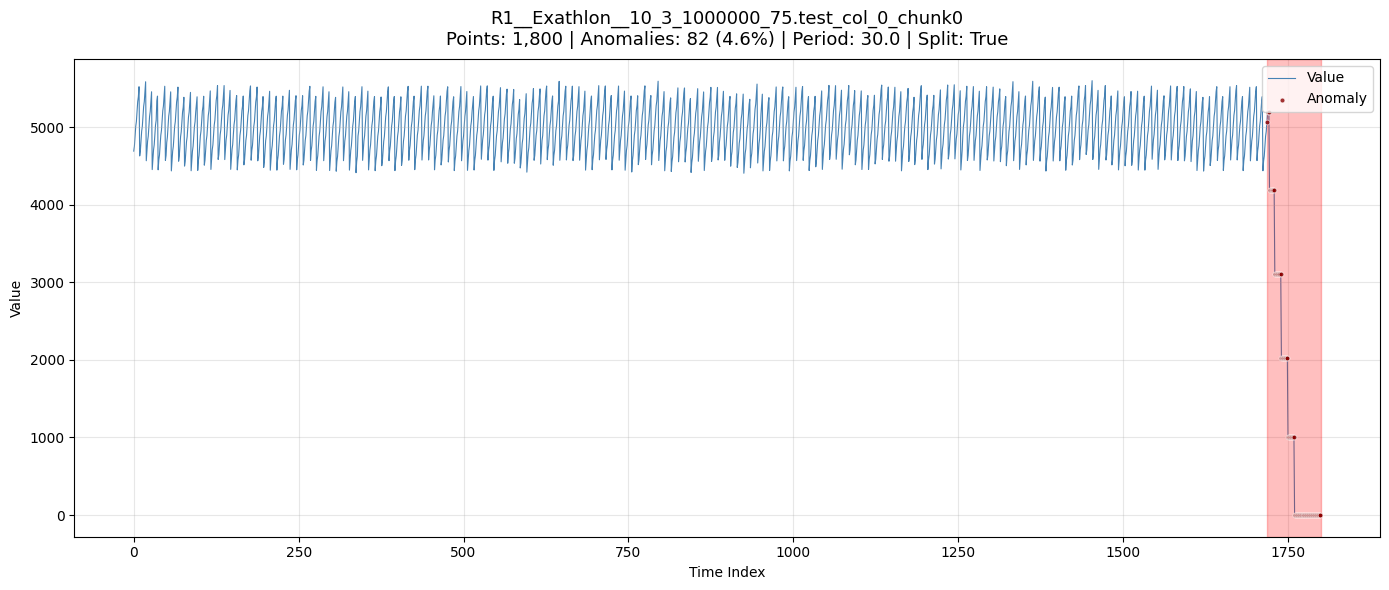


[2/10] Отображение: R1__Exathlon__10_3_1000000_75.test_col_0_chunk1
🔹Серия: R1__Exathlon__10_3_1000000_75.test_col_0_chunk1
🔹Точек: 6,407 | Аномалий: 961 (15.0%) | y_i=1
🔹Метаданные: period=30.0, split=True, orig_len=46590, anomaly_ratio=0.150


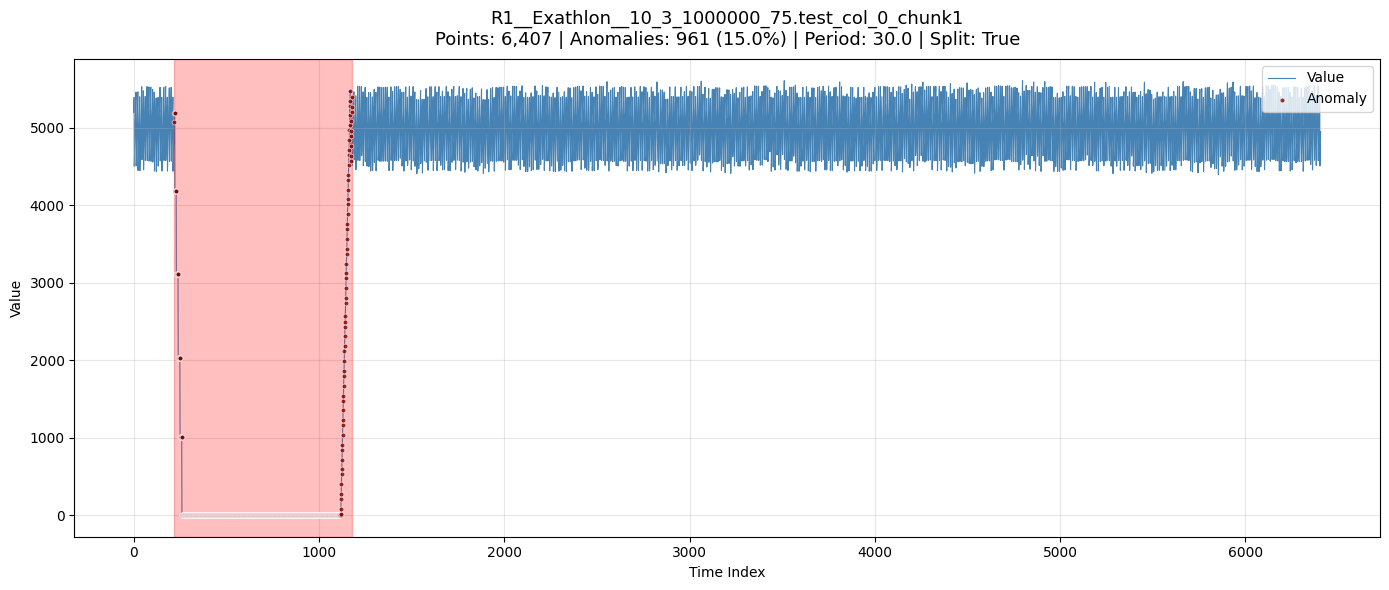


[3/10] Отображение: R1__Exathlon__10_3_1000000_75.test_col_0_chunk2
🔹Серия: R1__Exathlon__10_3_1000000_75.test_col_0_chunk2
🔹Точек: 6,474 | Аномалий: 971 (15.0%) | y_i=1
🔹Метаданные: period=30.0, split=True, orig_len=46590, anomaly_ratio=0.150


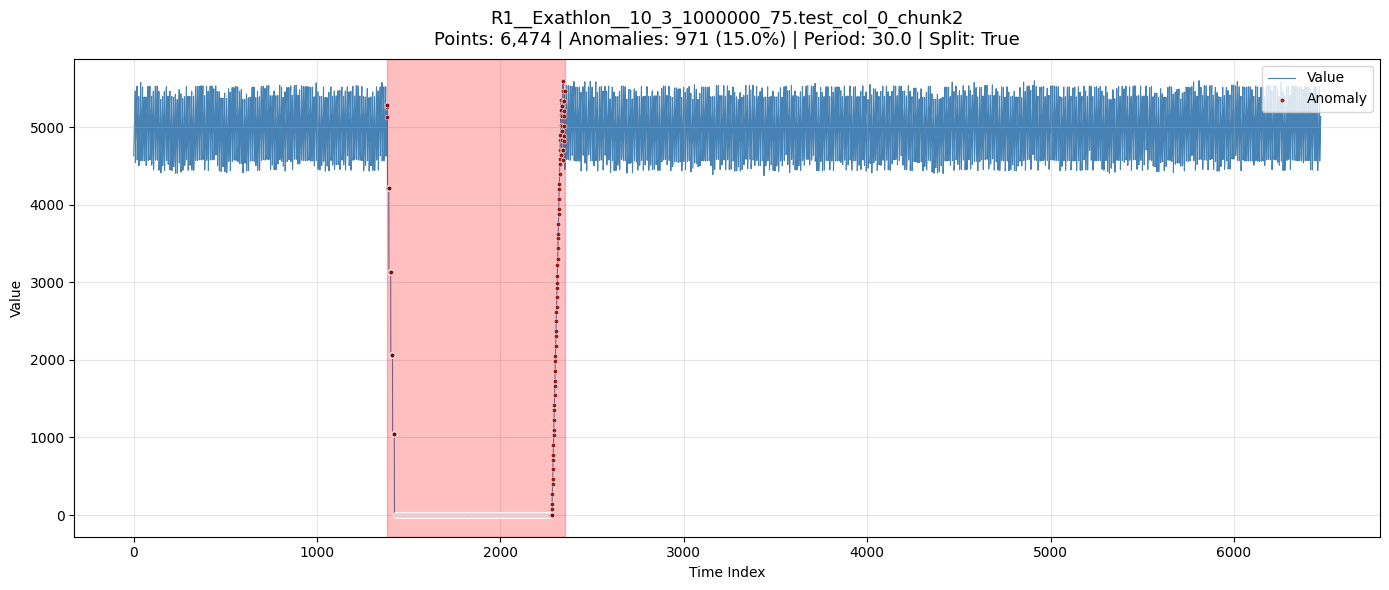


[4/10] Отображение: R1__Exathlon__10_3_1000000_75.test_col_0_chunk3
🔹Серия: R1__Exathlon__10_3_1000000_75.test_col_0_chunk3
🔹Точек: 1,800 | Аномалий: 127 (7.1%) | y_i=1
🔹Метаданные: period=30.0, split=True, orig_len=46590, anomaly_ratio=0.071


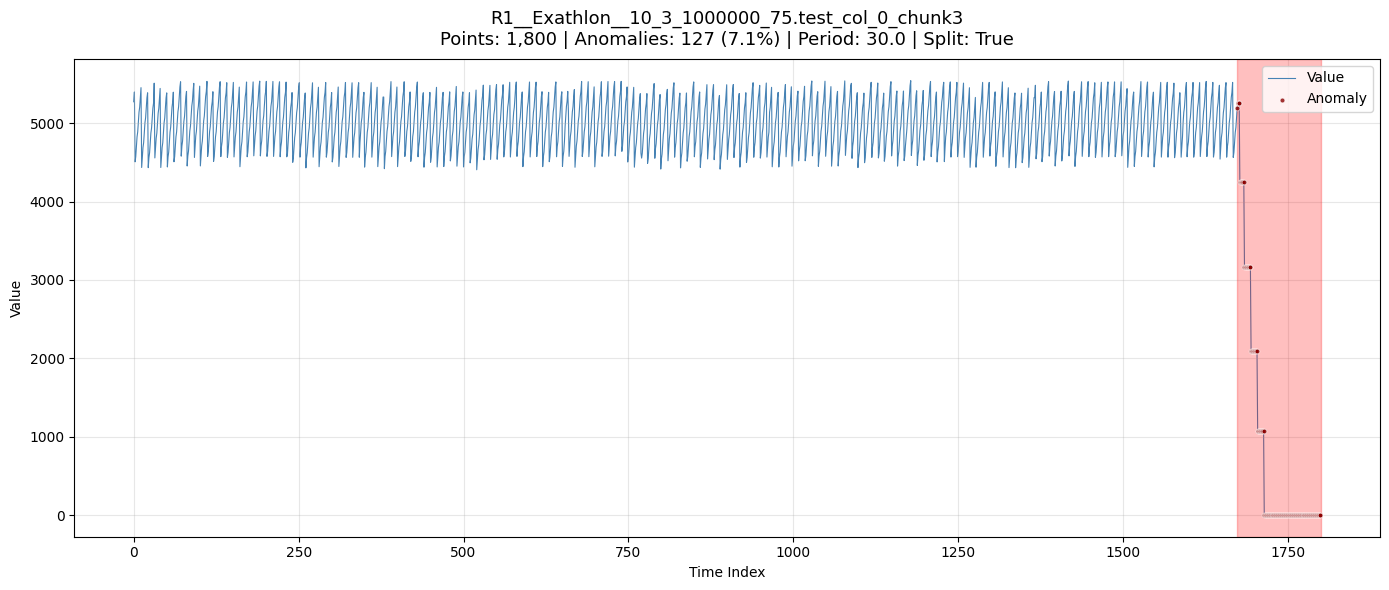


[5/10] Отображение: R1__Exathlon__10_3_1000000_75.test_col_0_chunk4
🔹Серия: R1__Exathlon__10_3_1000000_75.test_col_0_chunk4
🔹Точек: 6,687 | Аномалий: 1190 (17.8%) | y_i=1
🔹Метаданные: period=30.0, split=True, orig_len=46590, anomaly_ratio=0.178


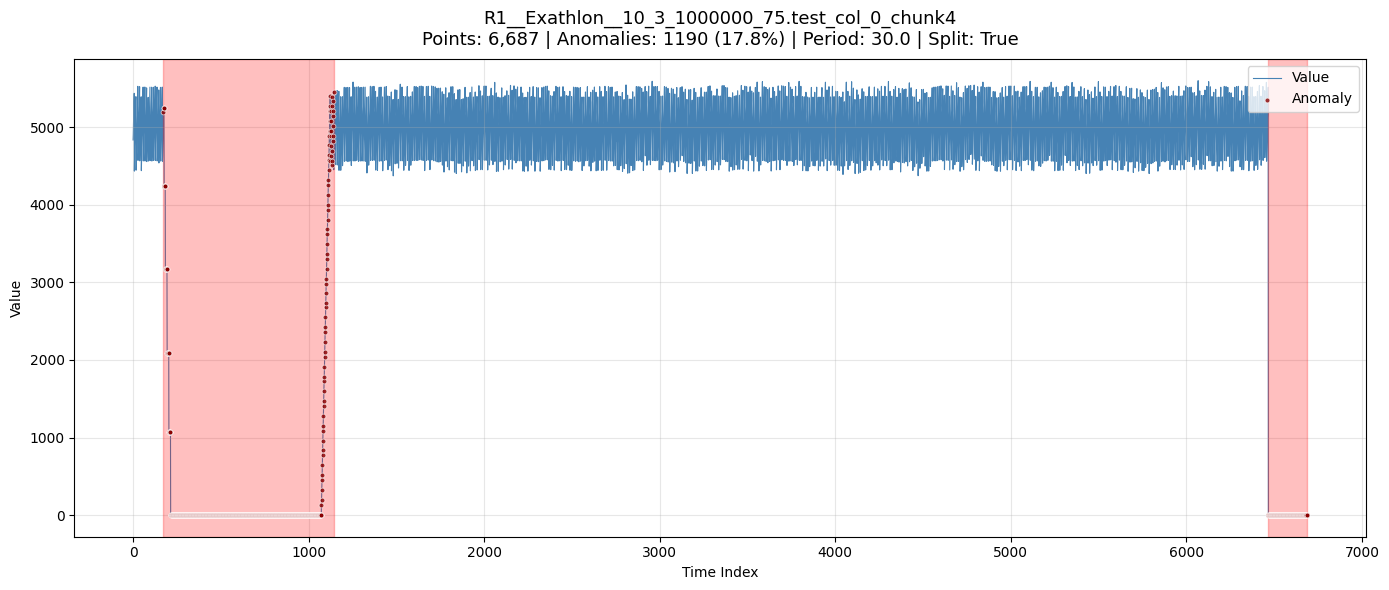


[6/10] Отображение: R1__Exathlon__10_3_1000000_75.test_col_1_chunk0
🔹Серия: R1__Exathlon__10_3_1000000_75.test_col_1_chunk0
🔹Точек: 1,800 | Аномалий: 80 (4.4%) | y_i=1
🔹Метаданные: period=30.0, split=True, orig_len=46592, anomaly_ratio=0.044


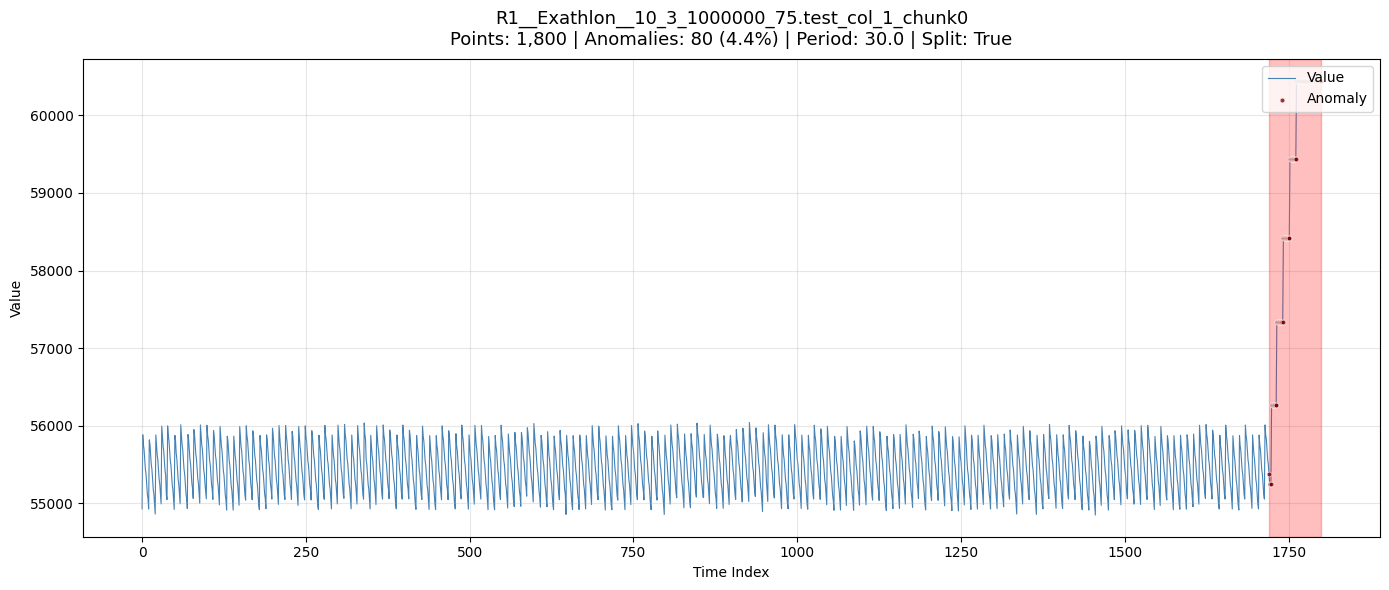


[7/10] Отображение: R1__Exathlon__10_3_1000000_75.test_col_1_chunk1
🔹Серия: R1__Exathlon__10_3_1000000_75.test_col_1_chunk1
🔹Точек: 6,407 | Аномалий: 961 (15.0%) | y_i=1
🔹Метаданные: period=30.0, split=True, orig_len=46592, anomaly_ratio=0.150


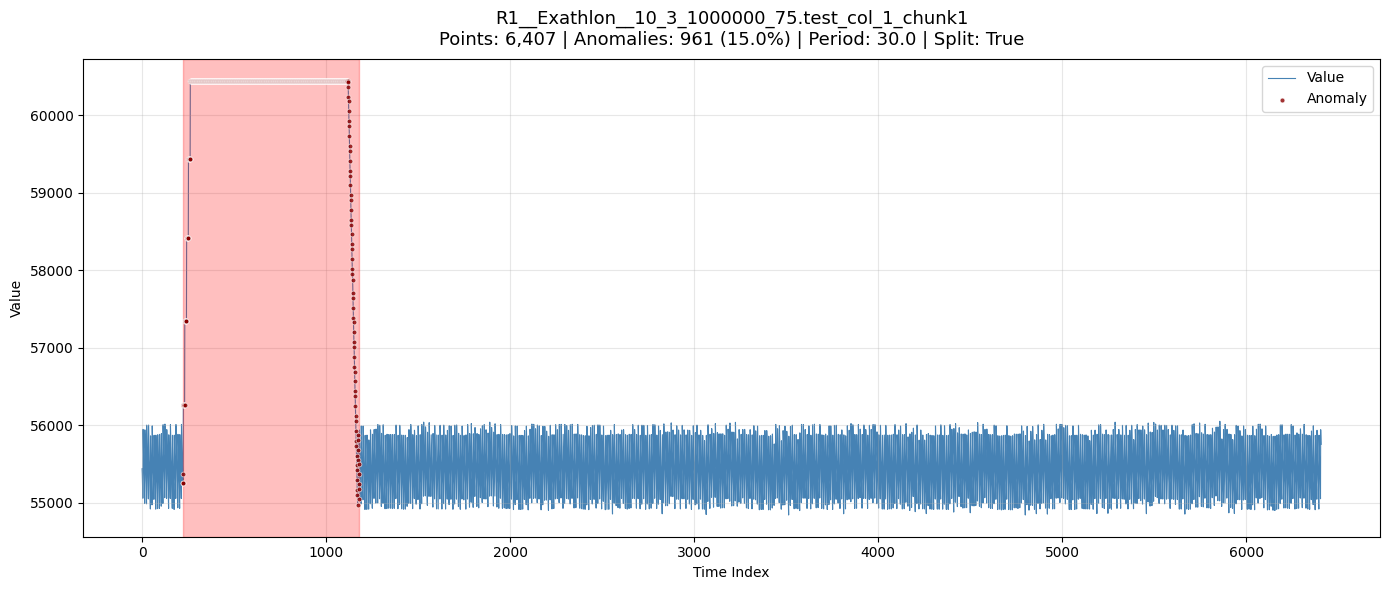


[8/10] Отображение: R1__Exathlon__10_3_1000000_75.test_col_1_chunk2
🔹Серия: R1__Exathlon__10_3_1000000_75.test_col_1_chunk2
🔹Точек: 6,474 | Аномалий: 971 (15.0%) | y_i=1
🔹Метаданные: period=30.0, split=True, orig_len=46592, anomaly_ratio=0.150


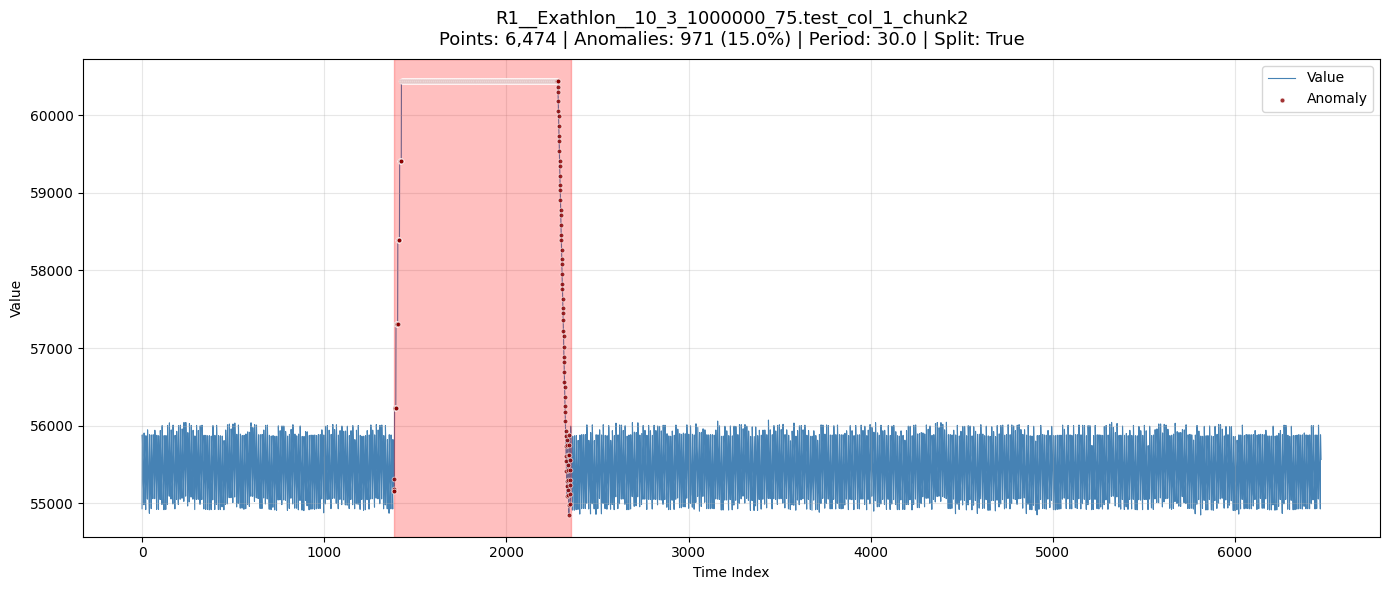


[9/10] Отображение: R1__Exathlon__10_3_1000000_75.test_col_1_chunk3
🔹Серия: R1__Exathlon__10_3_1000000_75.test_col_1_chunk3
🔹Точек: 1,800 | Аномалий: 125 (6.9%) | y_i=1
🔹Метаданные: period=30.0, split=True, orig_len=46592, anomaly_ratio=0.069


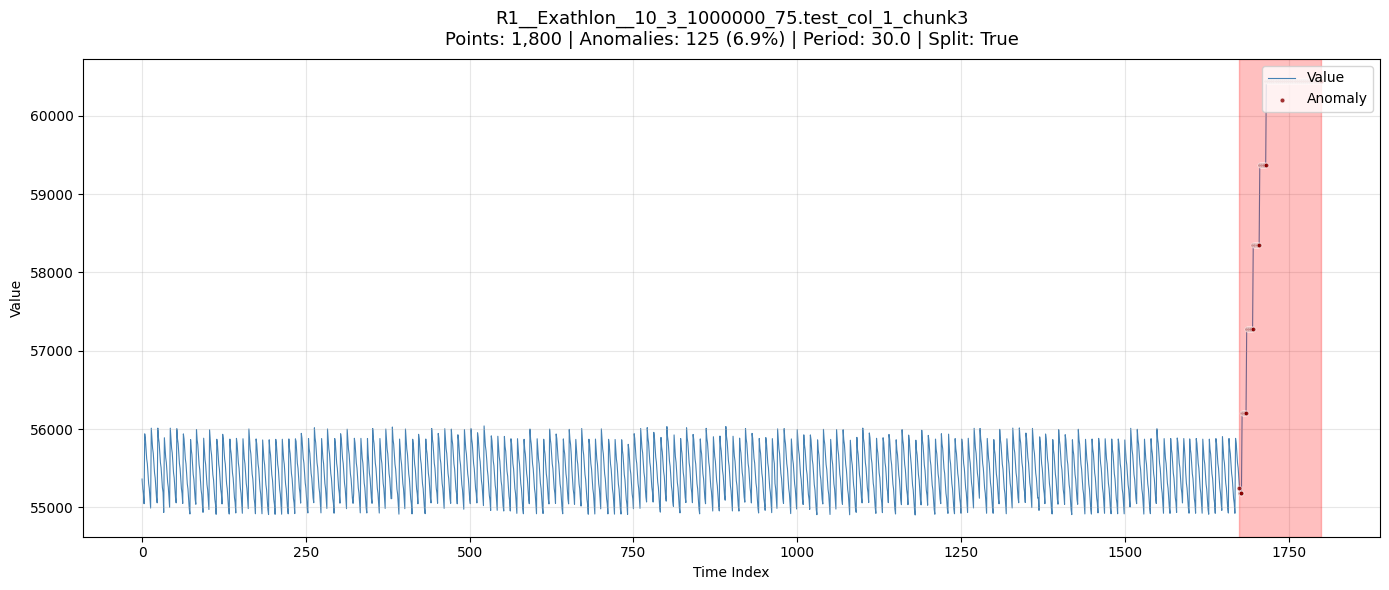


[10/10] Отображение: R1__Exathlon__10_3_1000000_75.test_col_1_chunk4
🔹Серия: R1__Exathlon__10_3_1000000_75.test_col_1_chunk4
🔹Точек: 6,689 | Аномалий: 1192 (17.8%) | y_i=1
🔹Метаданные: period=30.0, split=True, orig_len=46592, anomaly_ratio=0.178


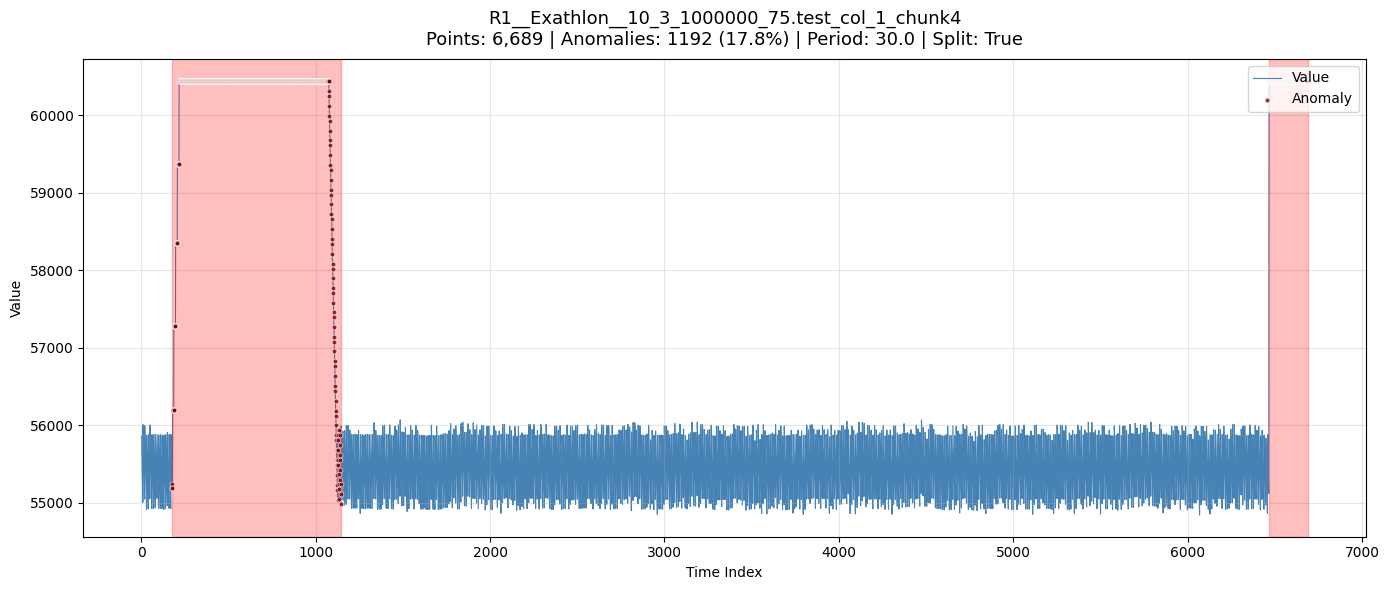

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

r1_path = "../data/R1.parquet"
r1_meta_path = "../data/R1_metadata.parquet"

df = pd.read_parquet(r1_path)
unique_series = df['series_id'].unique()
r1_meta = pd.read_parquet(r1_meta_path)

print(f"Найдено уникальных рядов: {len(unique_series)}")
count_to_show = 10  

for i, series_id in enumerate(unique_series[:count_to_show]):
    print(f"\n[{i+1}/{count_to_show}] Отображение: {series_id}")
    plot_real_series( 
        pool_file=r1_path,
        series_id=series_id,
        metadata_df=r1_meta   
    )

Найдено уникальных рядов: 11486

[1/10] Отображение: R2__LTDB__14157_col_0_chunk0
🔹Серия: R2__LTDB__14157_col_0_chunk0
🔹Точек: 1,638 | Аномалий: 0 (0.0%) | y_i=0
🔹Метаданные: period=107.0, split=True, orig_len=9454080, anomaly_ratio=0.000


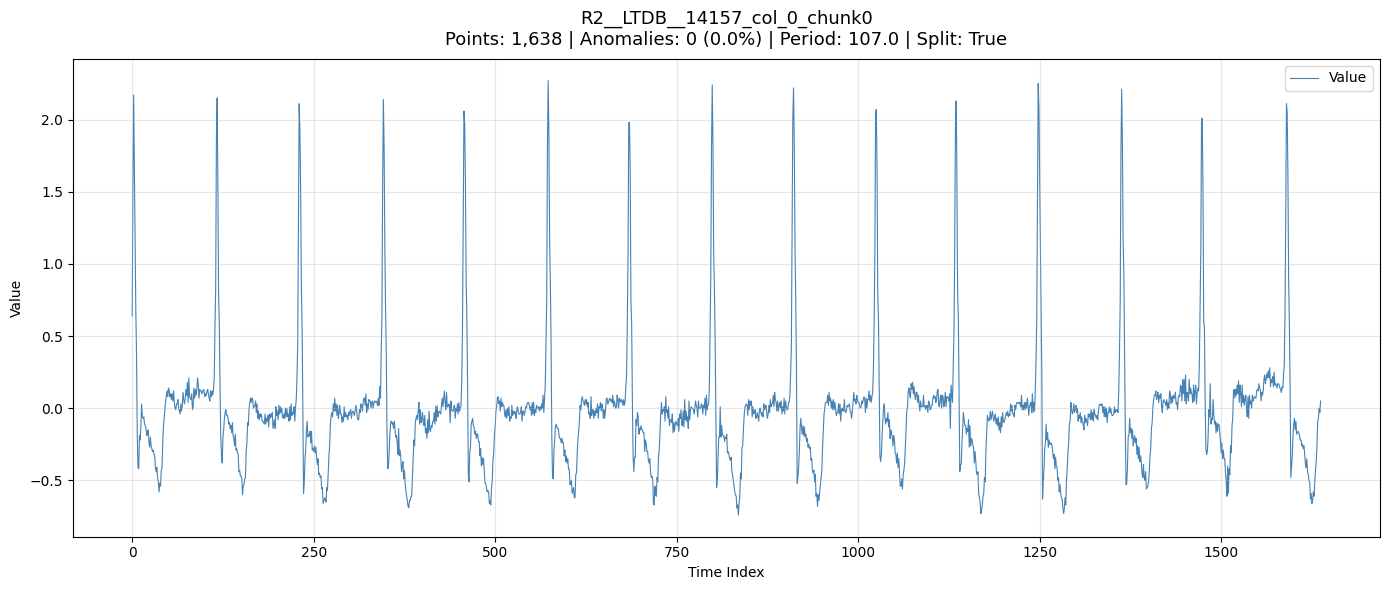


[2/10] Отображение: R2__LTDB__14157_col_0_chunk1
🔹Серия: R2__LTDB__14157_col_0_chunk1
🔹Точек: 1,605 | Аномалий: 371 (23.1%) | y_i=1
🔹Метаданные: period=107.0, split=True, orig_len=9454080, anomaly_ratio=0.231


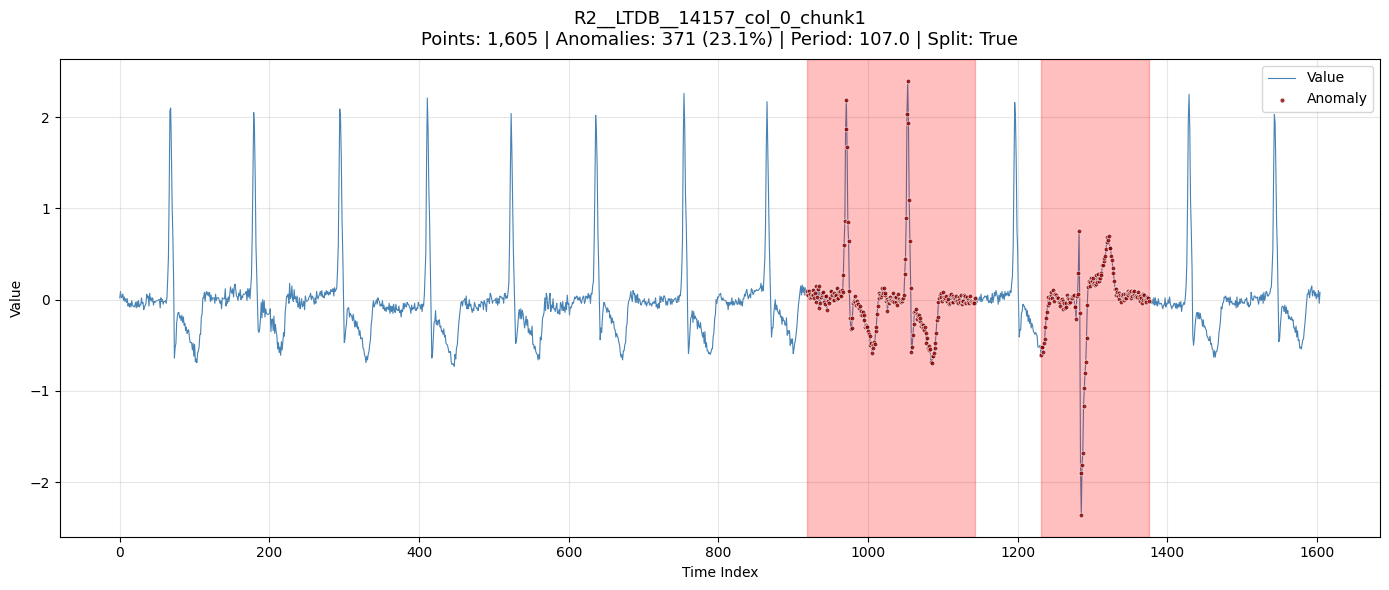


[3/10] Отображение: R2__LTDB__14157_col_0_chunk2
🔹Серия: R2__LTDB__14157_col_0_chunk2
🔹Точек: 1,605 | Аномалий: 0 (0.0%) | y_i=0
🔹Метаданные: period=107.0, split=True, orig_len=9454080, anomaly_ratio=0.000


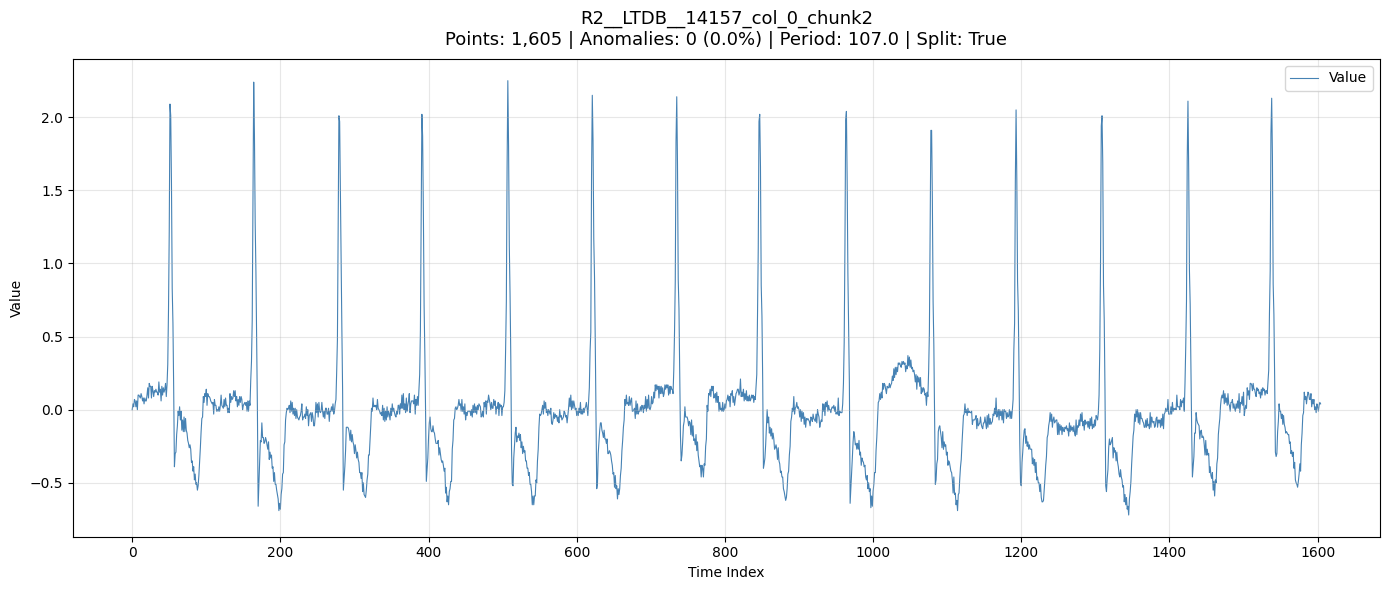


[4/10] Отображение: R2__LTDB__14157_col_0_chunk3
🔹Серия: R2__LTDB__14157_col_0_chunk3
🔹Точек: 1,675 | Аномалий: 0 (0.0%) | y_i=0
🔹Метаданные: period=107.0, split=True, orig_len=9454080, anomaly_ratio=0.000


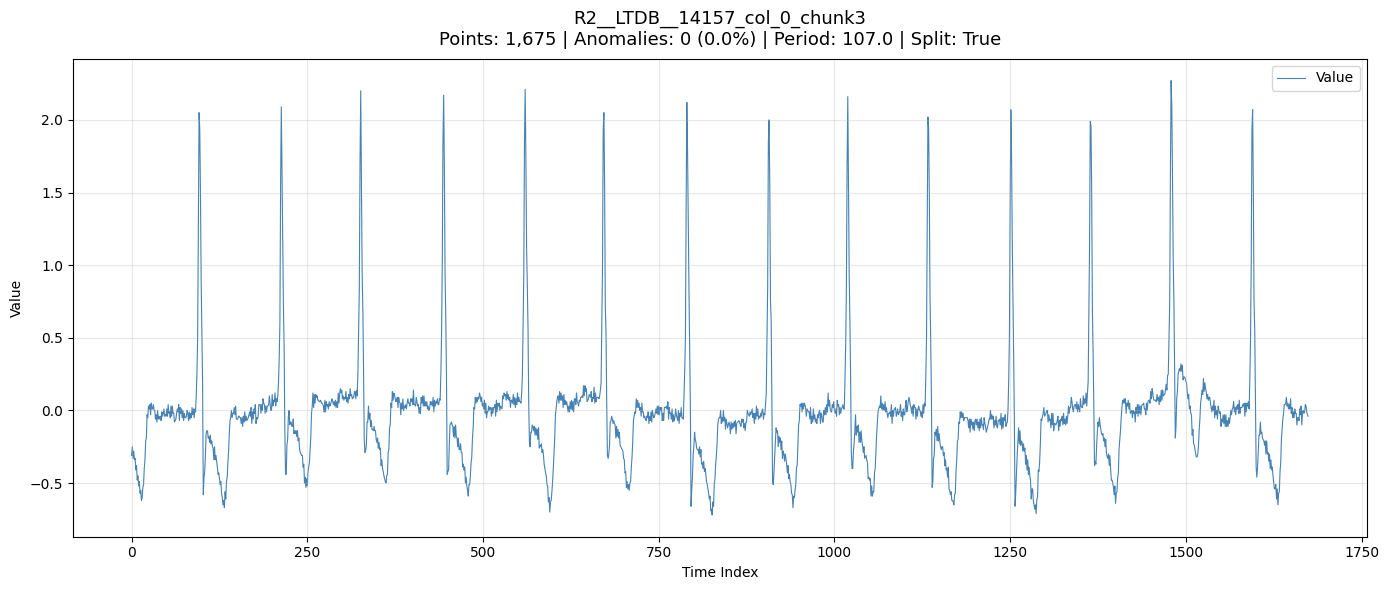


[5/10] Отображение: R2__LTDB__14157_col_0_chunk4
🔹Серия: R2__LTDB__14157_col_0_chunk4
🔹Точек: 1,606 | Аномалий: 147 (9.2%) | y_i=1
🔹Метаданные: period=107.0, split=True, orig_len=9454080, anomaly_ratio=0.091


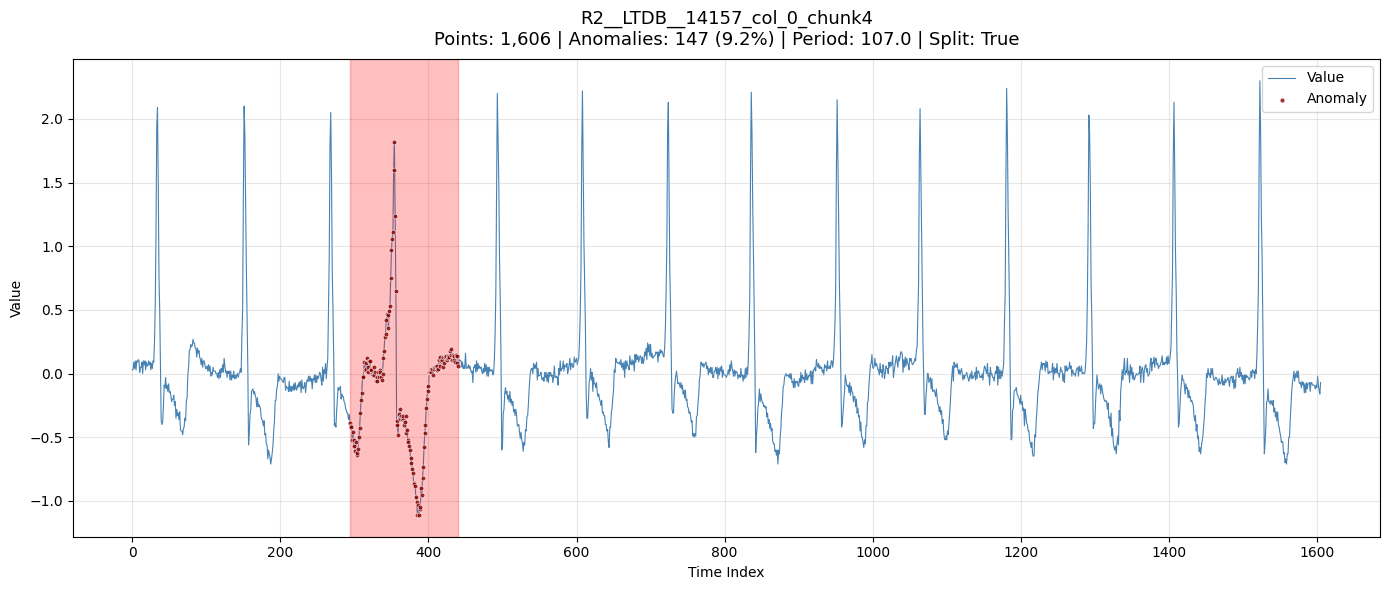


[6/10] Отображение: R2__LTDB__14157_col_0_chunk5
🔹Серия: R2__LTDB__14157_col_0_chunk5
🔹Точек: 1,605 | Аномалий: 286 (17.8%) | y_i=1
🔹Метаданные: period=107.0, split=True, orig_len=9454080, anomaly_ratio=0.178


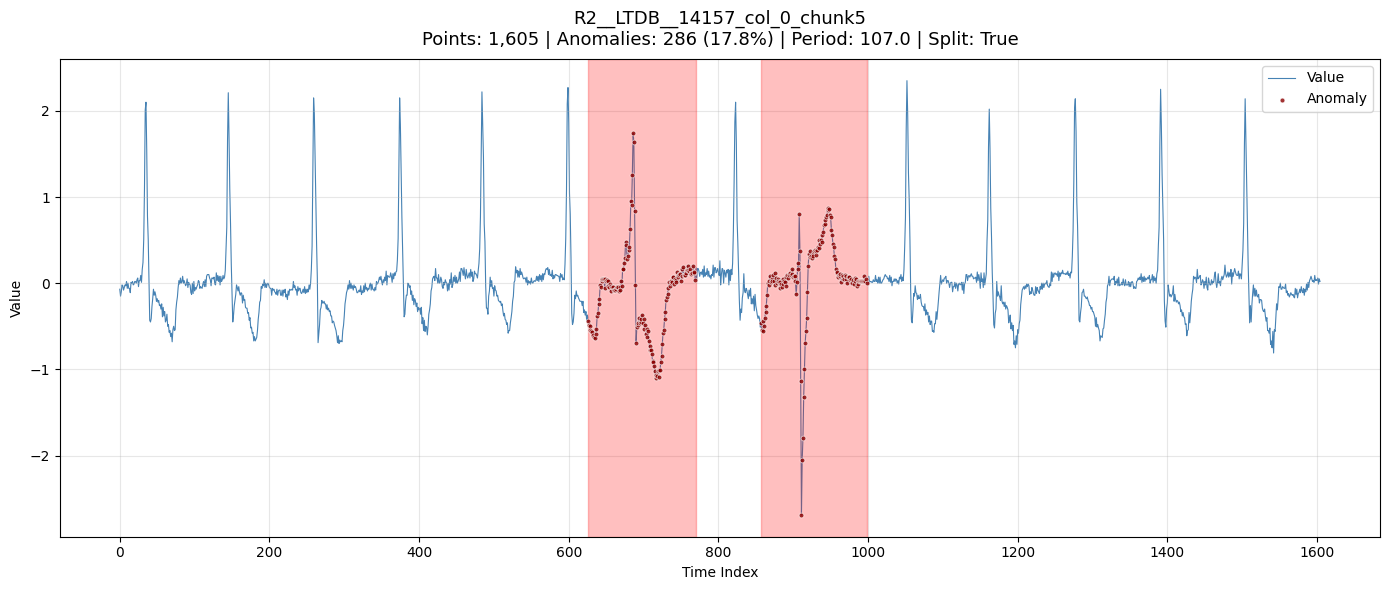


[7/10] Отображение: R2__LTDB__14157_col_0_chunk6
🔹Серия: R2__LTDB__14157_col_0_chunk6
🔹Точек: 12,267 | Аномалий: 1840 (15.0%) | y_i=1
🔹Метаданные: period=107.0, split=True, orig_len=9454080, anomaly_ratio=0.150


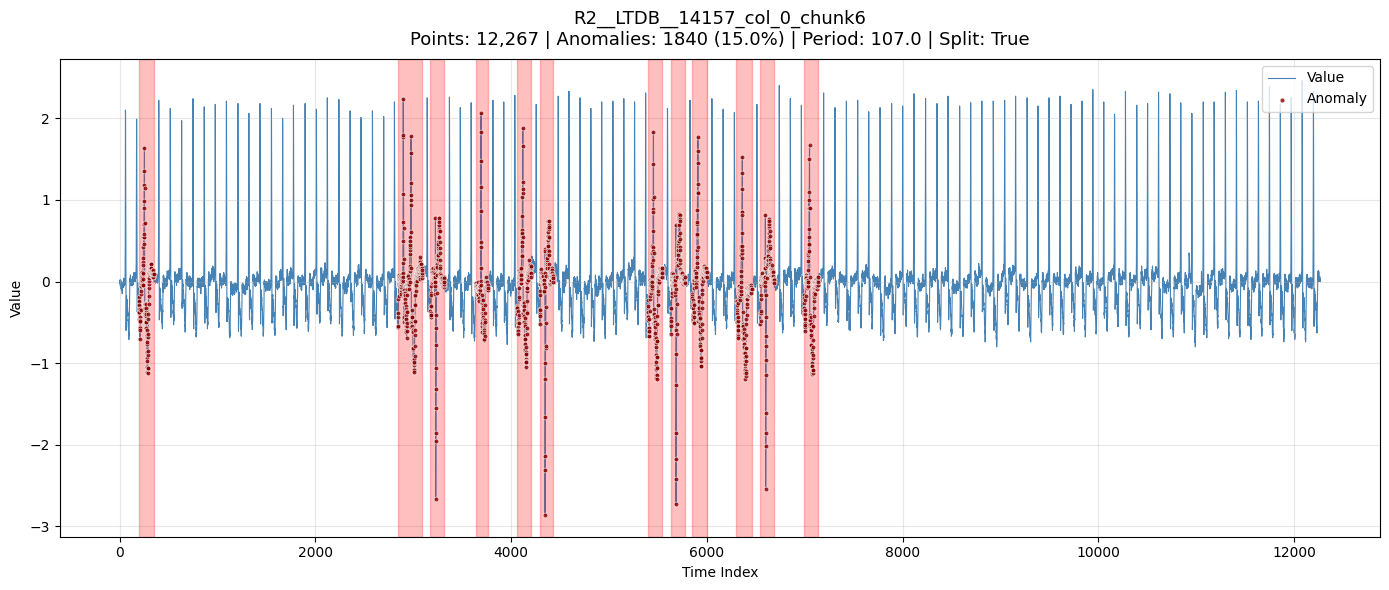


[8/10] Отображение: R2__LTDB__14157_col_0_chunk7
🔹Серия: R2__LTDB__14157_col_0_chunk7
🔹Точек: 1,712 | Аномалий: 389 (22.7%) | y_i=1
🔹Метаданные: period=107.0, split=True, orig_len=9454080, anomaly_ratio=0.227


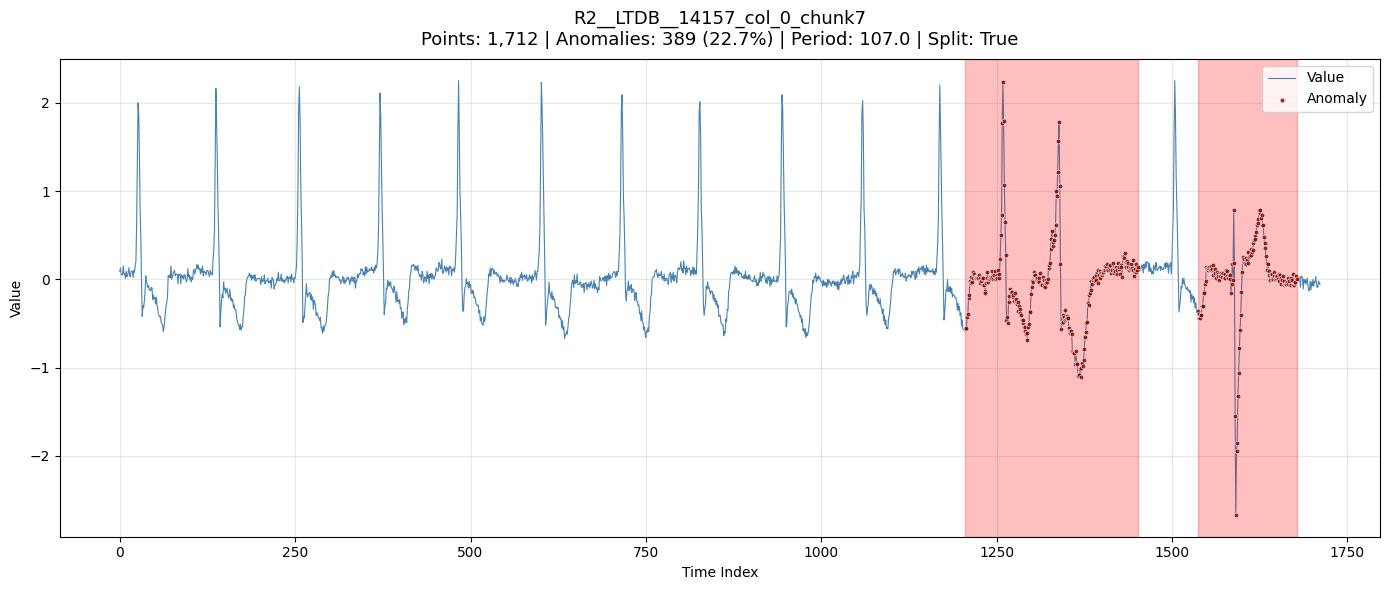


[9/10] Отображение: R2__LTDB__14157_col_0_chunk8
🔹Серия: R2__LTDB__14157_col_0_chunk8
🔹Точек: 32,434 | Аномалий: 4865 (15.0%) | y_i=1
🔹Метаданные: period=107.0, split=True, orig_len=9454080, anomaly_ratio=0.150


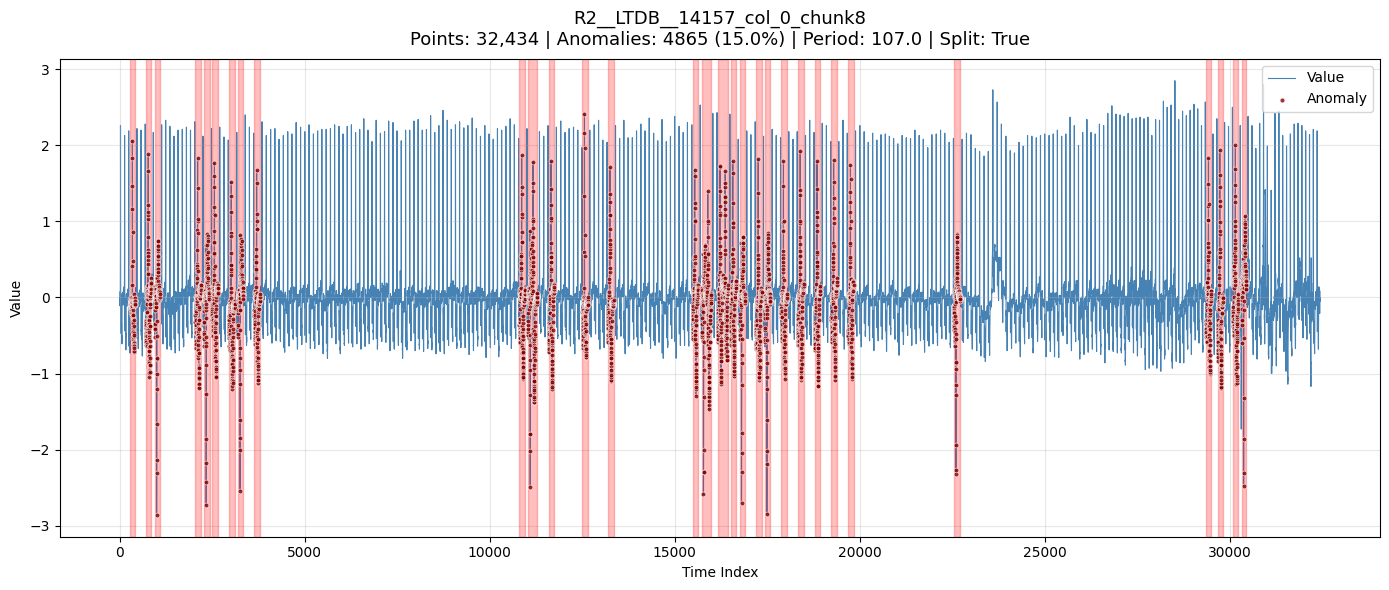


[10/10] Отображение: R2__LTDB__14157_col_0_chunk9
🔹Серия: R2__LTDB__14157_col_0_chunk9
🔹Точек: 26,247 | Аномалий: 3937 (15.0%) | y_i=1
🔹Метаданные: period=107.0, split=True, orig_len=9454080, anomaly_ratio=0.150


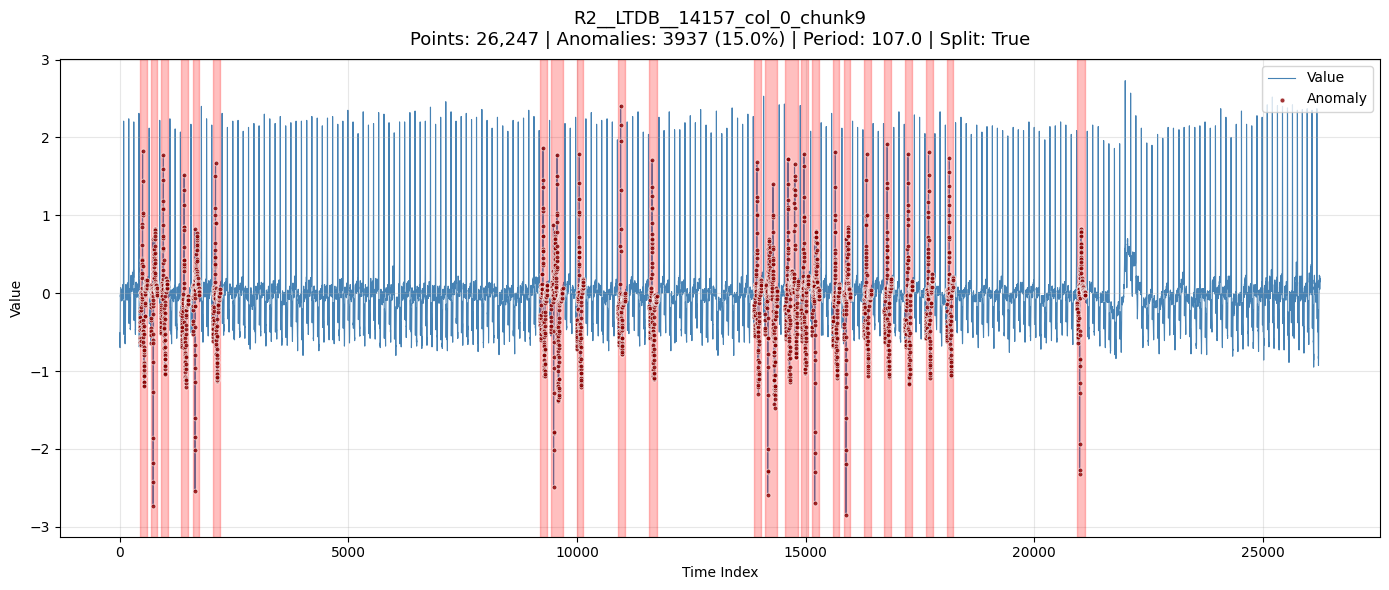

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

r1_path = "../data/R2.parquet"
r1_meta_path = "../data/R2_metadata.parquet"

df = pd.read_parquet(r1_path)
unique_series = df['series_id'].unique()
r1_meta = pd.read_parquet(r1_meta_path)

print(f"Найдено уникальных рядов: {len(unique_series)}")
count_to_show = 10  

for i, series_id in enumerate(unique_series[:count_to_show]):
    print(f"\n[{i+1}/{count_to_show}] Отображение: {series_id}")
    plot_real_series( 
        pool_file=r1_path,
        series_id=series_id,
        metadata_df=r1_meta   
    )